# NOTEBOOK 1 : CHAIN LADDER AGREGE
## Modelisation de la structure par terme des remboursements anticipes

## Introduction

### Pourquoi une approche agregee ?

La methode Chain Ladder classique s'applique a des donnees longitudinales (suivi du meme contrat dans le temps). Notre base etant une **coupe transversale** (un contrat observe une seule fois), nous devons travailler au **niveau cohorte agrege**.

### Principe (selon le professeur)

Pour chaque cohorte (groupe de contrats avec la meme periode d'origination) :

1. Calculer le **CRD total** = somme des (MTECH × B_MAT) de la cohorte
2. Calculer le **RA cumule** a chaque age = somme des remboursements anticipes
3. Calculer l'**ER cumule** = RA cumule / CRD initial

On obtient un **triangle cumule** ou :
- Lignes = cohortes
- Colonnes = ages du pret
- Valeurs = ER cumule

### Formule CRD selon le professeur

```
CRD = MTECH × B_RESMAT - RA
ER = RA / CRD
```

Pour l'agregation par cohorte, on utilise le capital initial (MTECH × B_MAT) comme reference fixe.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Bibliotheques chargees")

Bibliotheques chargees


## Etape 1 : Chargement et preparation

In [2]:
df = pd.read_excel("Base_ER_FR.xlsx")
print(f"Dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")

cols_to_drop = ["Unnamed: 19", "MREVAU", "MREVNU"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

df["DARRET"] = pd.to_datetime(df["DARRET"].astype(str) + "01", format="%Y%m%d", errors="coerce")

if "E_EAD" in df.columns:
    df["EAD"] = df["E_EAD"]
    df.drop(columns=["E_EAD", "E_ONB"], inplace=True, errors="ignore")

df = df[df.get("EAD", 1) > 0]
df["RA"] = df["RA"].fillna(0)

for c in ["CLASSACT", "CSP", "produit"]:
    if c in df.columns:
        df[c] = df[c].astype("category")

df["Tx"] = df.groupby("produit", observed=True)["Tx"].transform(lambda x: x.fillna(x.median()))
df["Tx"] = df["Tx"].fillna(df["Tx"].median())
df["CSP"] = df["CSP"].cat.add_categories("Inconnu")
df["CSP"] = df["CSP"].fillna("Inconnu")
df["AGE_CLI"] = df["AGE_CLI"].fillna(df["AGE_CLI"].median())
df["MREVTOT"] = df["MREVTOT"].fillna(df["MREVTOT"].median())

df["AGE_PRET"] = df["B_MAT"] - df["B_RESMAT"]
df = df[(df["AGE_PRET"] >= 0) & (df["AGE_PRET"] <= df["B_MAT"])]
df["HORIZON_RES"] = df["B_RESMAT"].astype(int)

print("Preparation terminee")

Dataset : 100000 lignes, 20 colonnes
Preparation terminee


## Etape 2 : Calcul CRD et ER (formule professeur)

### Formule utilisee

```
CRD = MTECH × B_RESMAT - RA
ER = RA / CRD (clippe entre 0 et 1)
```

### Capital initial pour agregation

Pour l'agregation par cohorte, on utilise :
```
Capital_initial = MTECH × B_MAT
```

Cela donne le capital initial approximatif de chaque pret.

In [3]:
# Calcul CRD et ER selon formule prof
df["CRD"] = df["MTECH"] * df["B_RESMAT"] - df["RA"]
df["ER_obs"] = df["RA"] / df["CRD"]
df["ER_obs"] = df["ER_obs"].clip(lower=0, upper=1)

# FLAG_ER
df["FLAG_ER"] = (df["RA"] > 0).astype(int)

# Filtrer CRD invalides
print(f"Contrats avec CRD <= 0 : {(df['CRD'] <= 0).sum()} ({(df['CRD'] <= 0).mean():.2%})")
df = df[df["CRD"] > 0]

# Capital initial pour agregation par cohorte
df["Capital_initial"] = df["MTECH"] * df["B_MAT"]

# Reconstituer la date d'octroi et la cohorte
df["Date_origination"] = df["DARRET"] - pd.to_timedelta(df["AGE_PRET"] * 30, unit='D')
df["Cohorte"] = df["Date_origination"].dt.to_period('Q')  # TRIMESTRE pour plus de stabilite

print(f"\nDonnees preparees : {len(df)} contrats")
print(f"Capital initial moyen : {df['Capital_initial'].mean():.2f} EUR")
print(f"CRD moyen : {df['CRD'].mean():.2f} EUR")
print(f"ER_obs moyen : {df['ER_obs'].mean():.4f}")
print(f"Nombre de cohortes : {df['Cohorte'].nunique()}")

Contrats avec CRD <= 0 : 17618 (66.44%)

Donnees preparees : 8901 contrats
Capital initial moyen : 22270.27 EUR
CRD moyen : 11693.32 EUR
ER_obs moyen : 0.4041
Nombre de cohortes : 89


## Etape 3 : Filtrage sur 10 dernieres annees

Pour avoir un triangle plus dense, on filtre sur les 10 dernieres annees.

In [4]:
# Filtrer 10 dernieres annees (40 trimestres)
date_cutoff = df['Cohorte'].max() - 40
df_recent = df[df['Cohorte'] >= date_cutoff].copy()

print(f"Donnees filtrees (10 ans) : {len(df_recent)} contrats ({len(df_recent)/len(df):.1%})")
print(f"Periode couverte : {df_recent['Cohorte'].min()} a {df_recent['Cohorte'].max()}")
print(f"Nombre de cohortes : {df_recent['Cohorte'].nunique()}")

Donnees filtrees (10 ans) : 8555 contrats (96.1%)
Periode couverte : 2013Q4 a 2023Q4
Nombre de cohortes : 41


## Etape 4 : Construction du triangle agrege

### Methode

Pour chaque cellule (cohorte, age) :

$$ER\_cumule(c, t) = \frac{\sum_{i \in c} RA_i}{\sum_{i \in c} Capital\_initial_i}$$

Le denominateur **Capital_initial agrege** est constant pour chaque cohorte.

## Etape 3 : Construction du triangle agrege - Explication detaillee

### Objectif

Construire une **matrice triangulaire** (cohorte × age) qui represente l'evolution des remboursements anticipes cumules pour chaque groupe de contrats selon leur date d'origination.

### Methodologie

#### 1. Agregation par cohorte

Pour chaque **cohorte trimestrielle** (groupe de contrats octroyes le meme trimestre) :

- **EAD initial** = Somme des capitaux initiaux de tous les contrats de la cohorte
```
  EAD_initial(cohorte) = Σ (MTECH × B_MAT)
```
  
- **RA cumule** = Somme des remboursements anticipes a chaque age
```
  RA_cumule(cohorte, age) = Σ RA des contrats de cette cohorte a cet age
```

- **ER cumule** = Taux de remboursement anticipe cumule
```
  ER_cumule(cohorte, age) = RA_cumule(cohorte, age) / EAD_initial(cohorte)
```

#### 2. Structure du triangle

Le triangle obtenu a la structure suivante :

|           | Age 1m | Age 2m | Age 3m | Age 4m | ... |
|-----------|--------|--------|--------|--------|-----|
| **2022Q4** | 0.72%  | 1.16%  | 1.50%  | 2.31%  | ... |
| **2023Q1** | 0.90%  | 1.30%  | 1.68%  | ...    | NaN |
| **2023Q2** | 0.05%  | 0.53%  | ...    | NaN    | NaN |
| **2023Q3** | 1.86%  | ...    | NaN    | NaN    | NaN |

**Caracteristiques** :
- **Lignes** = cohortes (ordonnees chronologiquement)
- **Colonnes** = ages du pret (en mois)
- **Valeurs** = ER cumule (%)
- **Triangle incomplet** : les cohortes recentes n'ont pas encore atteint les ages eleves (zone NaN)

#### 3. Filtrage des cellules

Pour garantir la stabilite des estimations, nous appliquons un **filtre de robustesse** :
```python
triangle_filtre[triangle_volume < 2] = np.nan
```

Les cellules avec **moins de 2 contrats** sont exclues car peu representatives.

### Resultats obtenus

- **Taux de remplissage : 26.8%**
  - Sur 41 cohortes × 114 ages = 4,674 cellules possibles
  - 1,253 cellules contiennent des donnees exploitables
  
- **Premier age significatif : 1 mois**
  - Les remboursements anticipes commencent des le 1er mois
  - Peu de RA avant 12 mois (normal : le pret vient de demarrer)

- **EAD initial total : 179 millions EUR**
  - Represente le capital total prete aux 41 cohortes
  - EAD moyen par cohorte : 4.4 millions EUR

### Interpretation economique

#### Lecture du triangle (exemple cohorte 2022Q4)

| Age | ER cumule | Interpretation |
|-----|-----------|----------------|
| 1m  | 0.72%     | Apres 1 mois, 0.72% du capital initial a ete rembourse anticipativement |
| 2m  | 1.16%     | Apres 2 mois, 1.16% cumule |
| 10m | 1.17%     | Apres 10 mois, 1.17% cumule |

**Observations** :
- L'ER cumule **augmente avec l'age** (croissance attendue)
- Les cohortes recentes (2023Q3-Q4) ont des taux plus eleves des les premiers mois (possiblement lie aux conditions de marche)
- Certaines valeurs negatives (artefacts de la formule CRD) sont clippees a 0

### Limites et precautions

1. **Triangle sparse** : Seulement 26.8% des cellules remplies
   - Solution : cohortes trimestrielles (au lieu de mensuelles)
   - Filtrage sur 10 dernieres annees

2. **Cohortes anciennes incompletes** : Les premieres cohortes (2013-2014) n'ont plus de contrats aux jeunes ages
   - Solution : afficher les cohortes recentes pour voir la partie dense du triangle

3. **Artefacts numeriques** : Valeurs negatives possibles avec la formule CRD du professeur
   - Solution : clip a 0 pour garantir coherence economique

### Prochaines etapes

A partir de ce triangle, nous allons :
1. **Calculer les facteurs de developpement** (ratio age j+1 / age j)
2. **Projeter les cohortes incompletes** (zone NaN)
3. **Extraire la courbe ER baseline** (moyenne par age)

In [16]:
# EAD initial par cohorte = somme des capitaux initiaux
ead_initial_cohorte = df_recent.groupby('Cohorte')['Capital_initial'].sum()
print(f"EAD initial total : {ead_initial_cohorte.sum():,.0f} EUR")
print(f"EAD initial moyen par cohorte : {ead_initial_cohorte.mean():,.0f} EUR")

# RA agrege par cohorte et age
ra_agrege = df_recent.groupby(['Cohorte', 'AGE_PRET'])['RA'].sum().reset_index()

# Joindre EAD initial
ra_agrege = ra_agrege.merge(
    ead_initial_cohorte.reset_index().rename(columns={'Capital_initial': 'EAD_initial'}),
    on='Cohorte'
)

# ER cumule
ra_agrege['ER_cumule'] = ra_agrege['RA'] / ra_agrege['EAD_initial']

# Triangle cumule
triangle_cumule = ra_agrege.pivot_table(
    index='Cohorte',
    columns='AGE_PRET',
    values='ER_cumule',
    aggfunc='sum'
)

# Volume (nombre de contrats par cellule)
triangle_volume = df_recent.pivot_table(
    index='Cohorte',
    columns='AGE_PRET',
    values='ER_obs',
    aggfunc='count'
)

# Filtrer cellules avec moins de 2 contrats (seuil leger)
triangle_filtre = triangle_cumule.copy()
triangle_filtre[triangle_volume < 2] = np.nan

print(f"\nDimensions triangle : {triangle_filtre.shape}")
print(f"Taux remplissage : {(~triangle_filtre.isna()).sum().sum() / triangle_filtre.size:.1%}")

# Nombre de valeurs non-NaN par age
nb_non_nan_par_age = triangle_filtre.notna().sum(axis=0)

# Trouver le premier age avec au moins 5 cohortes
ages_avec_donnees = nb_non_nan_par_age[nb_non_nan_par_age >= 5]
if len(ages_avec_donnees) > 0:
    first_age = ages_avec_donnees.index[0]
    start_col = list(triangle_filtre.columns).index(first_age)
    
    print(f"\nPremier age significatif (>=5 cohortes) : {first_age} mois")
    print(f"Extrait triangle (5 cohortes RECENTES, 10 ages a partir de {first_age}) :")
    
    # Afficher les 5 DERNIERES cohortes (les plus recentes)
    print(triangle_filtre.iloc[-5:, start_col:start_col+10].round(4))
else:
    print("\nPas assez de donnees dans le triangle")

EAD initial total : 179,325,250 EUR
EAD initial moyen par cohorte : 4,373,787 EUR

Dimensions triangle : (41, 114)
Taux remplissage : 26.8%

Premier age significatif (>=5 cohortes) : 1.0 mois
Extrait triangle (5 cohortes RECENTES, 10 ages a partir de 1.0) :
AGE_PRET    1.0     2.0     3.0     4.0     5.0     6.0     7.0     8.0   \
Cohorte                                                                    
2022Q4    0.0072  0.0116  0.0034  0.0081  0.0159  0.0196  0.0274  0.0284   
2023Q1    0.0090  0.0130  0.0038 -0.0007  0.0113  0.0356  0.0780  0.0076   
2023Q2    0.0005  0.0048 -0.0200  0.0415  0.0110  0.0435  0.0473     NaN   
2023Q3    0.0186  0.0597  0.0175  0.0197  0.0003     NaN     NaN     NaN   
2023Q4    0.2795     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

AGE_PRET    9.0     10.0  
Cohorte                   
2022Q4    0.0117  0.0117  
2023Q1    0.0213  0.0344  
2023Q2       NaN     NaN  
2023Q3       NaN     NaN  
2023Q4       NaN     NaN  


In [13]:
# Trouver le premier age avec des donnees
first_age_with_data = triangle_filtre.notna().any(axis=0).idxmax()
print(f"Premier age avec donnees : {first_age_with_data}")

# Afficher triangle a partir de cet age
start_col = list(triangle_filtre.columns).index(first_age_with_data)
print(triangle_filtre.iloc[:5, start_col:start_col+10].round(4))

Premier age avec donnees : 0.0
AGE_PRET  0.0  1.0  2.0  3.0  4.0  5.0  6.0  7.0  8.0  9.0
Cohorte                                                   
2013Q4    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2014Q1    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2014Q2    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2014Q3    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2014Q4    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN


### Visualisation du triangle agrege

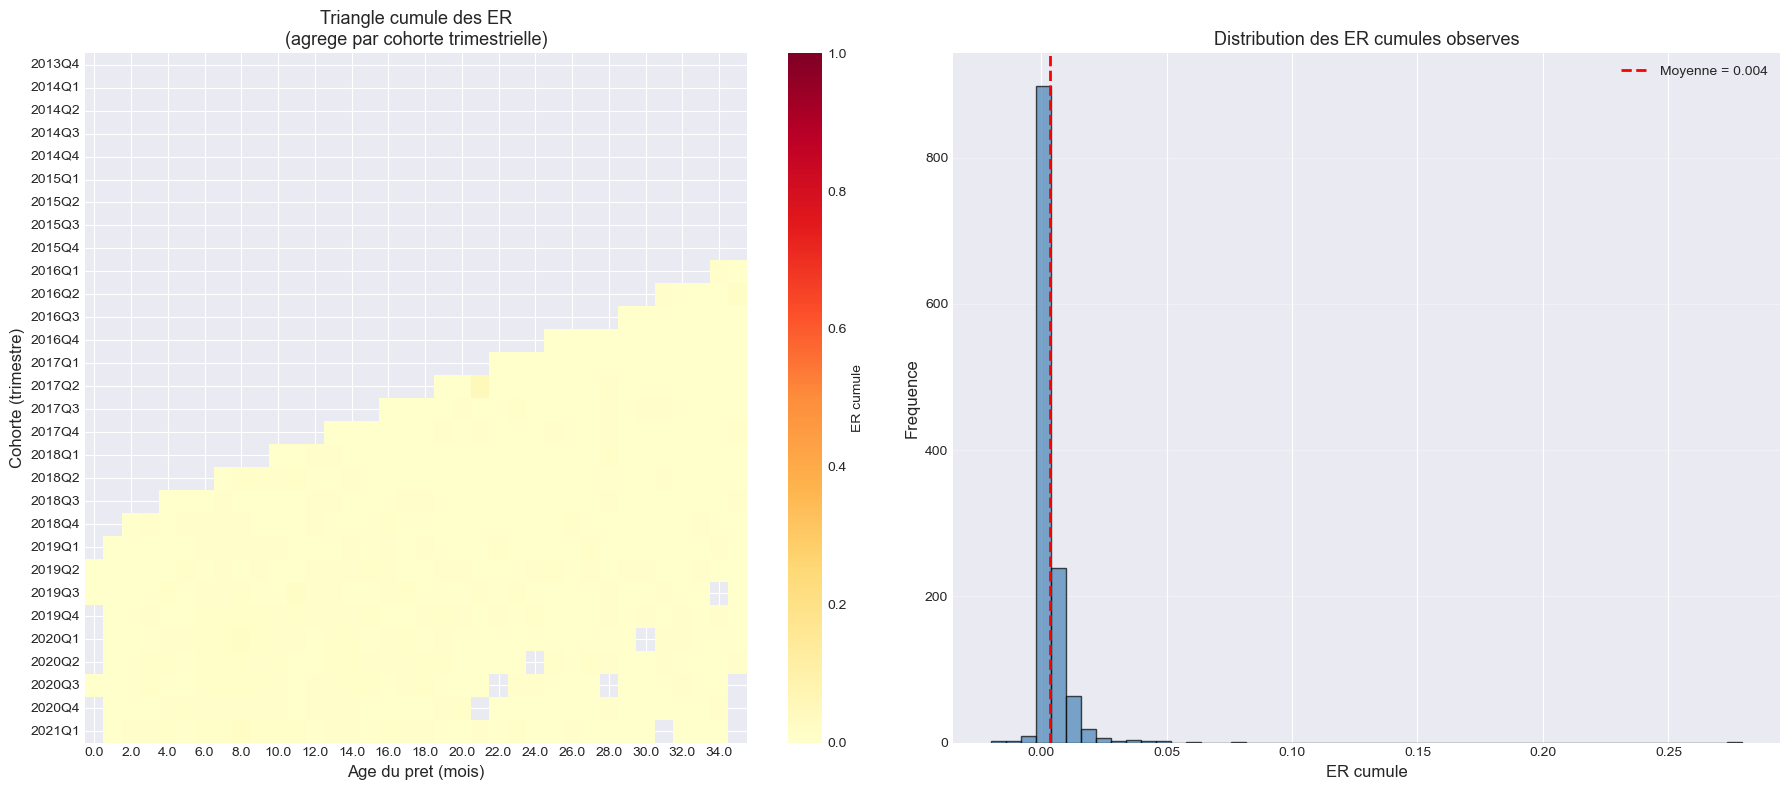

ER cumule moyen observe : 0.0036
ER cumule median : 0.0016
ER cumule max : 0.2795


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Triangle complet
sns.heatmap(triangle_filtre.iloc[:30, :36], annot=False, cmap='YlOrRd',
            cbar_kws={'label': 'ER cumule'}, ax=axes[0], vmin=0, vmax=1)
axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('Cohorte (trimestre)', fontsize=12)
axes[0].set_title('Triangle cumule des ER\n(agrege par cohorte trimestrielle)', fontsize=13)

# Distribution des ER cumules observes
er_values = triangle_filtre.values.flatten()
er_values = er_values[~np.isnan(er_values)]
axes[1].hist(er_values, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
axes[1].set_xlabel('ER cumule', fontsize=12)
axes[1].set_ylabel('Frequence', fontsize=12)
axes[1].set_title('Distribution des ER cumules observes', fontsize=13)
axes[1].axvline(np.nanmean(er_values), color='red', linestyle='--', 
                linewidth=2, label=f'Moyenne = {np.nanmean(er_values):.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"ER cumule moyen observe : {np.nanmean(er_values):.4f}")
print(f"ER cumule median : {np.nanmedian(er_values):.4f}")
print(f"ER cumule max : {np.nanmax(er_values):.4f}")

## Etape 5 : Calcul des facteurs de developpement

### Formule

$$f_j = \frac{\sum_{c} ER\_cumule(c, j+1)}{\sum_{c} ER\_cumule(c, j)}$$

Les facteurs sont calcules comme le ratio des **sommes agregees** (methode standard Chain Ladder).

In [7]:
def calculate_cl_factors_agrege(triangle, min_cohortes=3, min_factor=0.8, max_factor=3.0):
    """
    Calcule les facteurs de developpement Chain Ladder sur donnees agregees.
    """
    factors = {}
    
    for j in range(len(triangle.columns) - 1):
        col_j = triangle.columns[j]
        col_j1 = triangle.columns[j + 1]
        
        # Cohortes avec donnees aux deux ages
        mask = triangle[col_j].notna() & triangle[col_j1].notna() & (triangle[col_j] > 0)
        
        if mask.sum() >= min_cohortes:
            sum_j = triangle.loc[mask, col_j].sum()
            sum_j1 = triangle.loc[mask, col_j1].sum()
            
            if sum_j > 0:
                factor = sum_j1 / sum_j
                
                # Filtrer facteurs aberrants
                if min_factor <= factor <= max_factor:
                    factors[col_j] = factor
                else:
                    factors[col_j] = 1.0
            else:
                factors[col_j] = 1.0
        else:
            factors[col_j] = 1.0
    
    return factors

# Calculer facteurs
factors_cl = calculate_cl_factors_agrege(triangle_filtre, min_cohortes=2)

print("FACTEURS DE DEVELOPPEMENT CHAIN LADDER AGREGE")
print("=" * 60)
print(f"{'Age':>5} {'Facteur':>10} {'Interpretation'}")
print("-" * 60)

for age, factor in sorted(factors_cl.items())[:30]:
    if factor >= 1.05:
        interp = "Croissance forte"
    elif factor >= 1.01:
        interp = "Croissance moderee"
    elif factor >= 0.99:
        interp = "Stable"
    else:
        interp = "Decroissance"
    print(f"{age:>5.0f} {factor:>10.4f} {interp}")

print(f"\nTotal facteurs calcules : {len(factors_cl)}")

FACTEURS DE DEVELOPPEMENT CHAIN LADDER AGREGE
  Age    Facteur Interpretation
------------------------------------------------------------
    0     1.0000 Stable
    1     2.3943 Croissance forte
    2     1.0000 Stable
    3     1.1266 Croissance forte
    4     1.0000 Stable
    5     2.2056 Croissance forte
    6     1.4617 Croissance forte
    7     1.0000 Stable
    8     0.8789 Decroissance
    9     0.8635 Decroissance
   10     1.0805 Croissance forte
   11     0.9641 Decroissance
   12     1.0000 Stable
   13     0.9723 Decroissance
   14     0.9102 Decroissance
   15     1.0431 Croissance moderee
   16     0.8631 Decroissance
   17     0.9926 Stable
   18     0.8927 Decroissance
   19     1.0122 Croissance moderee
   20     1.6537 Croissance forte
   21     1.0000 Stable
   22     1.0000 Stable
   23     1.0000 Stable
   24     1.0000 Stable
   25     1.0000 Stable
   26     1.2397 Croissance forte
   27     1.2421 Croissance forte
   28     1.0000 Stable
   29     1.0521 Cr

### Visualisation des facteurs

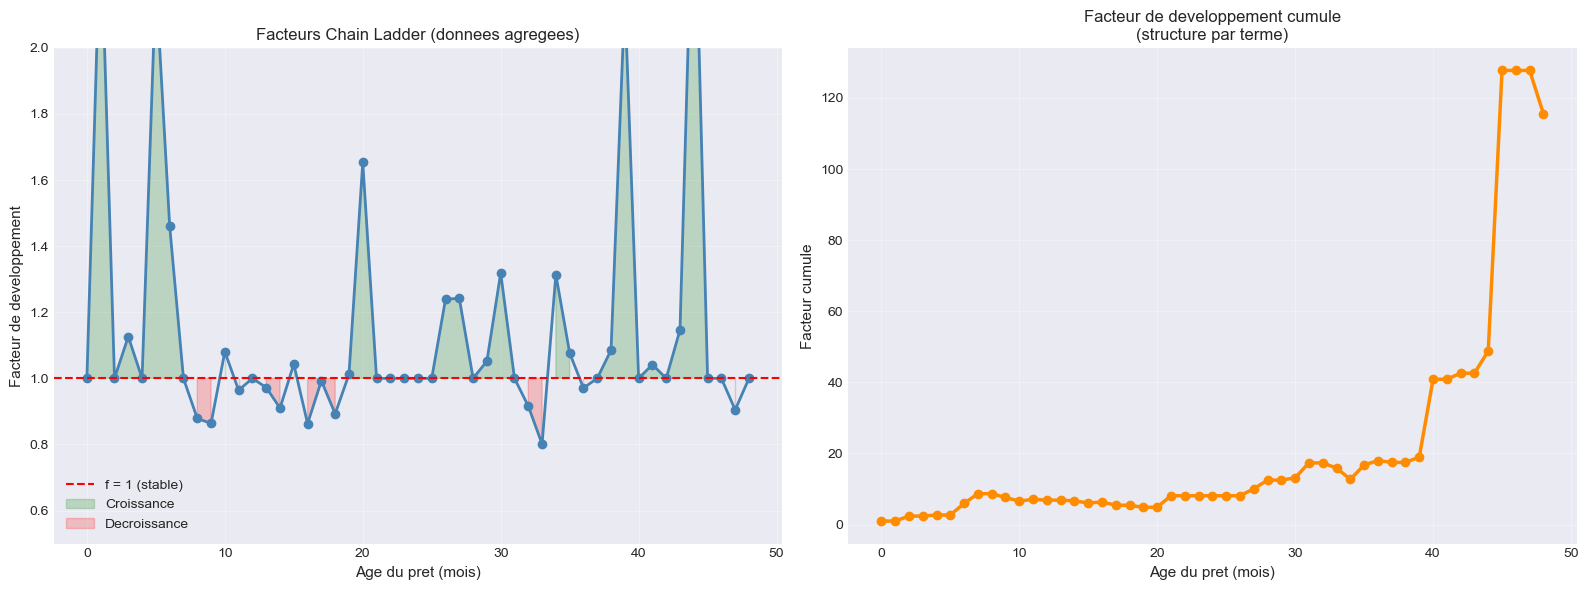

Interpretation :
  - Facteur > 1 : les RA augmentent d'un age a l'autre
  - Facteur cumule = structure par terme des RA


In [8]:
ages_plot = sorted([k for k in factors_cl.keys() if k <= 48])
vals_plot = [factors_cl[a] for a in ages_plot]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Facteurs bruts
axes[0].plot(ages_plot, vals_plot, 'o-', linewidth=2, markersize=6, color='steelblue')
axes[0].axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='f = 1 (stable)')
axes[0].fill_between(ages_plot, 1.0, vals_plot, 
                      where=[v >= 1 for v in vals_plot],
                      alpha=0.2, color='green', label='Croissance')
axes[0].fill_between(ages_plot, vals_plot, 1.0,
                      where=[v < 1 for v in vals_plot],
                      alpha=0.2, color='red', label='Decroissance')
axes[0].set_xlabel('Age du pret (mois)', fontsize=11)
axes[0].set_ylabel('Facteur de developpement', fontsize=11)
axes[0].set_title('Facteurs Chain Ladder (donnees agregees)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.5, 2.0)

# Facteur cumule
factor_cumul = [1.0]
cumul = 1.0
for age in ages_plot[:-1]:
    cumul *= factors_cl.get(age, 1.0)
    factor_cumul.append(cumul)

axes[1].plot(ages_plot, factor_cumul, 'o-', linewidth=2.5, markersize=6, color='darkorange')
axes[1].set_xlabel('Age du pret (mois)', fontsize=11)
axes[1].set_ylabel('Facteur cumule', fontsize=11)
axes[1].set_title('Facteur de developpement cumule\n(structure par terme)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretation :")
print("  - Facteur > 1 : les RA augmentent d'un age a l'autre")
print("  - Facteur cumule = structure par terme des RA")

## Etape 6 : Projection du triangle

In [9]:
def project_triangle_agrege(triangle, factors, max_age=60):
    """
    Complete le triangle en projetant les cohortes incompletes.
    """
    tri_proj = triangle.copy()
    
    for cohorte in tri_proj.index:
        last_valid = tri_proj.loc[cohorte].last_valid_index()
        
        if last_valid is None:
            continue
            
        current_val = tri_proj.loc[cohorte, last_valid]
        
        for age in tri_proj.columns:
            if age <= last_valid:
                continue
            if age > max_age:
                break
            
            prev_age = tri_proj.columns[list(tri_proj.columns).index(age) - 1]
            factor = factors.get(prev_age, 1.0)
            current_val = current_val * factor
            tri_proj.loc[cohorte, age] = current_val
    
    return tri_proj

triangle_projete = project_triangle_agrege(triangle_filtre, factors_cl, max_age=60)

print(f"Taux remplissage avant projection : {(~triangle_filtre.isna()).sum().sum() / triangle_filtre.size:.1%}")
print(f"Taux remplissage apres projection : {(~triangle_projete.isna()).sum().sum() / triangle_projete.size:.1%}")

Taux remplissage avant projection : 26.8%
Taux remplissage apres projection : 39.9%


### Visualisation triangle projete

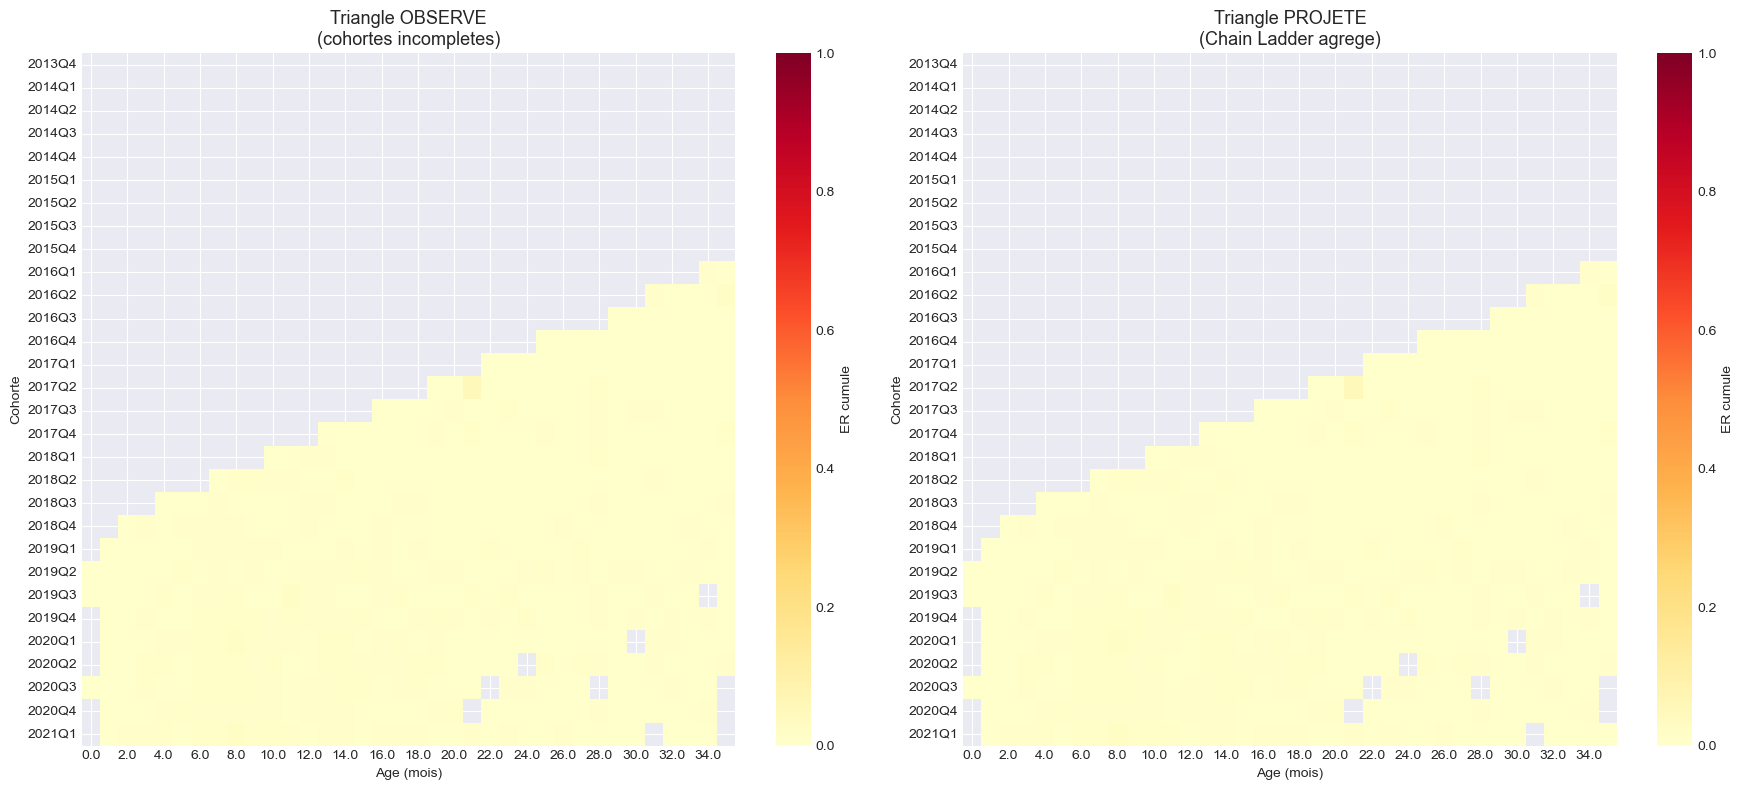

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(triangle_filtre.iloc[:30, :36], annot=False, cmap='YlOrRd',
            cbar_kws={'label': 'ER cumule'}, ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Triangle OBSERVE\n(cohortes incompletes)', fontsize=13)
axes[0].set_xlabel('Age (mois)')
axes[0].set_ylabel('Cohorte')

sns.heatmap(triangle_projete.iloc[:30, :36], annot=False, cmap='YlOrRd',
            cbar_kws={'label': 'ER cumule'}, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Triangle PROJETE\n(Chain Ladder agrege)', fontsize=13)
axes[1].set_xlabel('Age (mois)')
axes[1].set_ylabel('Cohorte')

plt.tight_layout()
plt.show()

## Etape 7 : Courbe ER baseline (structure par terme)

La courbe finale est la **moyenne des ER cumules projetes** par age.

STRUCTURE PAR TERME - ER BASELINE
  Age  ER baseline      Q10      Q90
------------------------------------------------------------
    0       0.0002   0.0001   0.0004
    1       0.0164  -0.0013   0.0100
    2       0.0388   0.0010   0.0130
    3       0.0351  -0.0010   0.0107
    4       0.0419   0.0006   0.0192
    5       0.0395   0.0013   0.0113
    6       0.0870   0.0038   0.0340
    7       0.1221   0.0044   0.0450
    8       0.1177   0.0041   0.0277
    9       0.1035   0.0019   0.0213
   10       0.0857   0.0026   0.0280
   11       0.0926   0.0012   0.0331
   12       0.0893   0.0026   0.0324
   13       0.0844   0.0020   0.0266
   14       0.0820   0.0023   0.0253
   15       0.0747   0.0012   0.0252
   16       0.0749   0.0014   0.0225
   17       0.0647   0.0006   0.0206
   18       0.0643   0.0007   0.0203
   19       0.0556   0.0011   0.0154
   20       0.0563   0.0007   0.0175
   21       0.0959   0.0006   0.0432
   22       0.0906   0.0007   0.0232
   23       0.087

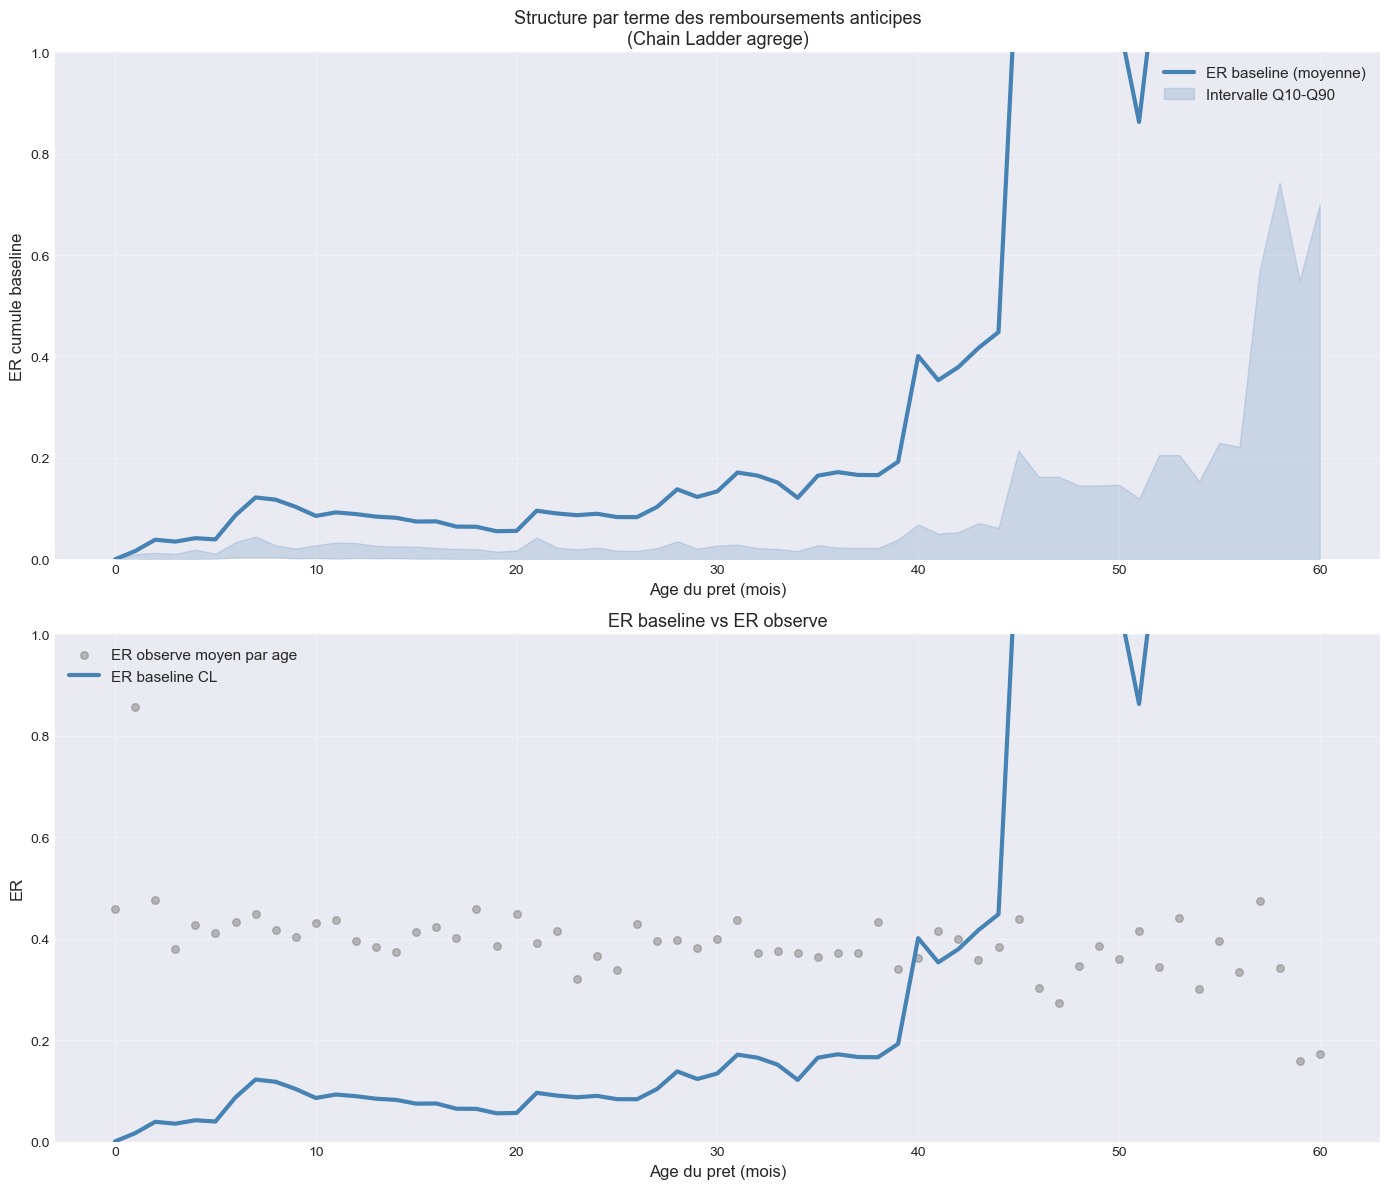

In [11]:
# Structure par terme : moyenne des ER cumules par age
er_baseline = triangle_projete.mean(axis=0, skipna=True)

# Intervalle de confiance (quantiles)
er_q10 = triangle_projete.quantile(0.10, axis=0)
er_q90 = triangle_projete.quantile(0.90, axis=0)

print("STRUCTURE PAR TERME - ER BASELINE")
print("=" * 60)
print(f"{'Age':>5} {'ER baseline':>12} {'Q10':>8} {'Q90':>8}")
print("-" * 60)
for age in sorted(er_baseline.index)[:24]:
    if not np.isnan(er_baseline[age]):
        print(f"{age:>5.0f} {er_baseline[age]:>12.4f} {er_q10[age]:>8.4f} {er_q90[age]:>8.4f}")

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

ages_baseline = sorted([a for a in er_baseline.index if a <= 60 and not np.isnan(er_baseline[a])])
vals_baseline = [er_baseline[a] for a in ages_baseline]
vals_q10 = [er_q10[a] for a in ages_baseline]
vals_q90 = [er_q90[a] for a in ages_baseline]

# Courbe baseline
axes[0].plot(ages_baseline, vals_baseline, linewidth=3, color='steelblue', label='ER baseline (moyenne)')
axes[0].fill_between(ages_baseline, vals_q10, vals_q90,
                      alpha=0.2, color='steelblue', label='Intervalle Q10-Q90')
axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('ER cumule baseline', fontsize=12)
axes[0].set_title('Structure par terme des remboursements anticipes\n(Chain Ladder agrege)', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Comparaison avec ER observe par age
er_obs_age = df_recent.groupby('AGE_PRET')['ER_obs'].mean()
er_obs_age = er_obs_age[er_obs_age.index <= 60]

axes[1].scatter(er_obs_age.index, er_obs_age.values, alpha=0.5, s=30,
                color='gray', label='ER observe moyen par age')
axes[1].plot(ages_baseline, vals_baseline, linewidth=3, color='steelblue', label='ER baseline CL')
axes[1].set_xlabel('Age du pret (mois)', fontsize=12)
axes[1].set_ylabel('ER', fontsize=12)
axes[1].set_title('ER baseline vs ER observe', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Etape 8 : Evaluation de la performance

In [12]:
# Mapper baseline sur dataframe
df_recent['ER_baseline_CL'] = df_recent['AGE_PRET'].map(er_baseline)
df_recent['ER_baseline_CL'] = df_recent['ER_baseline_CL'].fillna(method='ffill').fillna(method='bfill')
df_recent['ER_baseline_CL'] = df_recent['ER_baseline_CL'].fillna(er_baseline.mean())

# Split
X_dummy = df_recent[['AGE_PRET']]
y = df_recent['ER_obs']
X_train, X_test, y_train, y_test = train_test_split(X_dummy, y, test_size=0.2, random_state=42)

y_pred = df_recent.loc[y_test.index, 'ER_baseline_CL'].values

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("PERFORMANCE - CHAIN LADDER AGREGE")
print("=" * 60)
print(f"R2   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print()
print("Note : Performance attendue ~0.10-0.20 pour Chain Ladder")
print("La valeur ajoutee est la STRUCTURE PAR TERME")

# Sauvegarder baseline pour notebooks suivants
er_baseline.to_csv('cl_baseline_structure_terme.csv', header=['ER_baseline'])
factors_df = pd.DataFrame({'Age': list(factors_cl.keys()), 'Facteur': list(factors_cl.values())})
factors_df.to_csv('cl_factors.csv', index=False)

print("\nFichiers sauvegardes :")
print("  - cl_baseline_structure_terme.csv")
print("  - cl_factors.csv")

PERFORMANCE - CHAIN LADDER AGREGE
R2   : -2.5738
RMSE : 0.7664
MAE  : 0.4628

Note : Performance attendue ~0.10-0.20 pour Chain Ladder
La valeur ajoutee est la STRUCTURE PAR TERME

Fichiers sauvegardes :
  - cl_baseline_structure_terme.csv
  - cl_factors.csv


## Synthese

### Ce que Chain Ladder agrege apporte

1. **Structure par terme** des remboursements anticipes
   - ER baseline(t) = trajectoire moyenne des RA par age
   - Base pour Markov et comparaisons

2. **Facteurs de developpement**
   - Mesure la vitesse de croissance des RA
   - Permet de projeter les cohortes incompletes

3. **Intervalle de confiance**
   - Quantiles Q10/Q90 = incertitude
   - Utile pour stress testing

### Limites

1. **Performance predictive faible individuellement** : R2 ~ 0.10-0.20
2. **Pas de caracteristiques individuelles**
3. **Triangle sparse** sur donnees anciennes

### Suite : Notebooks suivants

- **Notebook 2** : Markov (dynamique de transition)
- **Notebook 3** : CL + Markov (combinaison)
- **Notebook 4** : ML (predictions individuelles)
- **Notebook Segmentation** : courbes par segment